In [2]:
!pip install scikit-learn matplotlib numpy pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [3]:
import os
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

ROOT = "../fiot_highway2-main"        # folder containing data/ and train.txt/test.txt
TRAIN_TXT = os.path.join(ROOT, "train.txt")
TEST_TXT  = os.path.join(ROOT, "test.txt")

NUM_CLASSES = 9
ORIG_SHAPE = (512, 243)   # original PSD shape

# Subsample sizes: keep these SMALL so it runs
MAX_TRAIN_SAMPLES = 2000   # try 1000–2000
MAX_TEST_SAMPLES  = 1000

# Downsample factors along freq and time
DS_FREQ = 4   # 512 -> 128
DS_TIME = 4   # 243 -> 61

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [4]:
def load_txt_list(txt_path):
    """
    txt file format: relative_path label
    returns: list of (full_path, label)
    """
    entries = np.loadtxt(txt_path, dtype=str).tolist()
    if isinstance(entries[0], str):
        entries = [entries]

    pairs = []
    for rel_path, label_str in entries:
        full_path = os.path.join(ROOT, rel_path)
        pairs.append((full_path, int(label_str)))
    return pairs


def load_psd_dataset_downsampled(pairs, max_samples=None, ds_f=4, ds_t=4):
    """
    Load PSDs, normalize, downsample, and flatten.

    pairs: list of (full_path, label)
    max_samples: cap on how many samples to load
    ds_f: downsample factor along frequency
    ds_t: downsample factor along time

    returns: X_flat (N, new_features), y (N,)
    """
    if max_samples is not None and max_samples < len(pairs):
        indices = np.random.choice(len(pairs), size=max_samples, replace=False)
        pairs = [pairs[i] for i in indices]

    X_list = []
    y_list = []

    for full_path, label in pairs:
        mat = np.load(full_path)  # (512, 243)

        # per-sample normalization
        mat = (mat - mat.mean()) / (mat.std() + 1e-6)

        # downsample: take every ds_f-th row and ds_t-th column
        mat_ds = mat[::ds_f, ::ds_t]  # e.g., (128, 61)

        X_list.append(mat_ds.flatten().astype(np.float32))
        y_list.append(label)

    X = np.stack(X_list)  # (N, features)
    y = np.array(y_list)
    return X, y


def plot_class_distribution(labels, title):
    counts = Counter(labels)
    classes = sorted(counts.keys())
    values = [counts[c] for c in classes]

    plt.figure(figsize=(7, 4))
    plt.bar(classes, values)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(title)
    plt.xticks(classes)
    plt.tight_layout()
    plt.show()

Total train examples listed: 12915
Total test  examples listed: 3296
Downsampled train shape: (2000, 7808) labels shape: (2000,)
Downsampled test shape:  (1000, 7808) labels shape: (1000,)


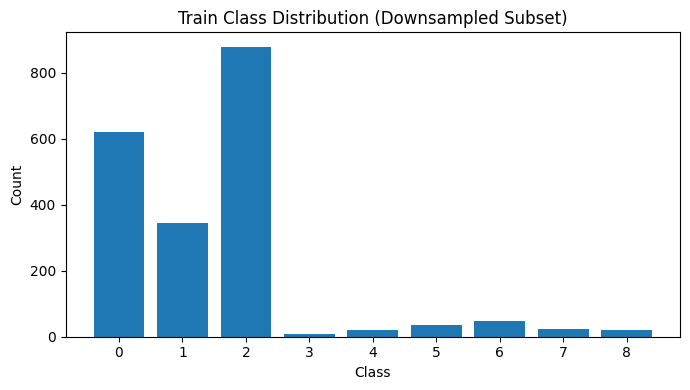

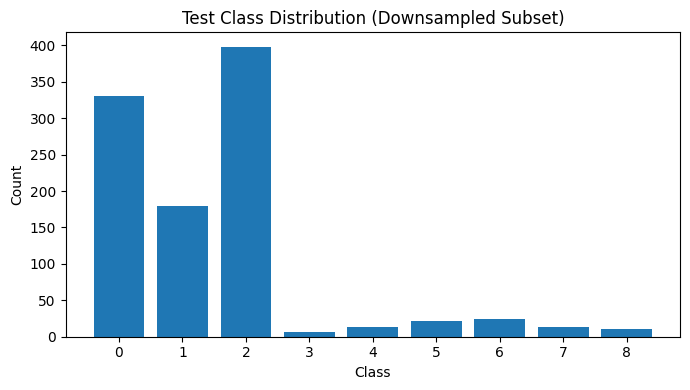

Train subset: (1600, 7808) Val subset: (400, 7808)


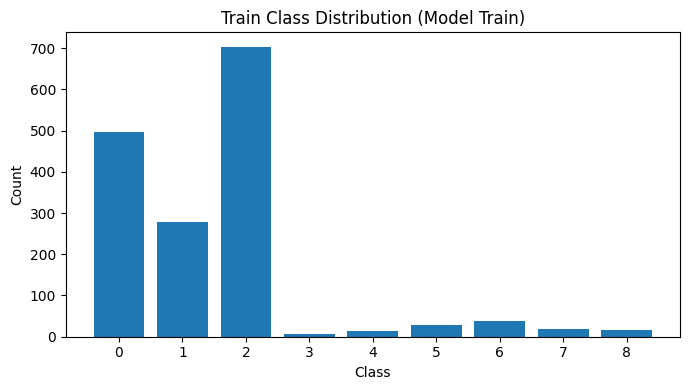

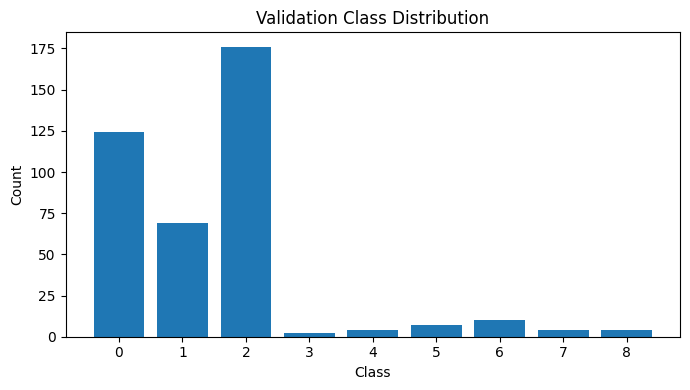

In [5]:
# Load file lists
train_pairs = load_txt_list(TRAIN_TXT)
test_pairs  = load_txt_list(TEST_TXT)

print("Total train examples listed:", len(train_pairs))
print("Total test  examples listed:", len(test_pairs))

# Load subsets into memory with normalization + downsampling + flattening
X_train, y_train = load_psd_dataset_downsampled(
    train_pairs,
    max_samples=MAX_TRAIN_SAMPLES,
    ds_f=DS_FREQ,
    ds_t=DS_TIME,
)
X_test,  y_test  = load_psd_dataset_downsampled(
    test_pairs,
    max_samples=MAX_TEST_SAMPLES,
    ds_f=DS_FREQ,
    ds_t=DS_TIME,
)

print("Downsampled train shape:", X_train.shape, "labels shape:", y_train.shape)
print("Downsampled test shape: ", X_test.shape,  "labels shape:", y_test.shape)

# Plot original distributions
plot_class_distribution(y_train.tolist(), "Train Class Distribution (Downsampled Subset)")
plot_class_distribution(y_test.tolist(),  "Test Class Distribution (Downsampled Subset)")

# Train/val split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_train,
)

print("Train subset:", X_tr.shape, "Val subset:", X_val.shape)
plot_class_distribution(y_tr.tolist(), "Train Class Distribution (Model Train)")
plot_class_distribution(y_val.tolist(), "Validation Class Distribution")

In [6]:
rf_bal = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_SEED,
)

print("Training Random Forest (Balanced) on downsampled features...")
rf_bal.fit(X_tr, y_tr)

y_tr_pred  = rf_bal.predict(X_tr)
y_val_pred = rf_bal.predict(X_val)
y_test_pred = rf_bal.predict(X_test)

acc_train = accuracy_score(y_tr, y_tr_pred)
acc_val   = accuracy_score(y_val, y_val_pred)
acc_test  = accuracy_score(y_test, y_test_pred)

results_df = pd.DataFrame([{
    "Model": "Random Forest (Downsampled, Balanced)",
    "Train Accuracy": acc_train,
    "Val Accuracy":   acc_val,
    "Test Accuracy":  acc_test,
}])

print("\n=== Model Accuracy ===")
print(results_df.to_string(index=False))

Training Random Forest (Balanced) on downsampled features...

=== Model Accuracy ===
                                Model  Train Accuracy  Val Accuracy  Test Accuracy
Random Forest (Downsampled, Balanced)             1.0        0.6625          0.638


Training Baseline Logistic Regression...
Training Class-Weighted Logistic Regression...
Training Random Forest (Downsampled, Balanced)...

=== FULL MODEL COMPARISON TABLE ===
                      Model  Train Accuracy  Val Accuracy  Test Accuracy
                   Baseline             1.0        0.6575          0.627
             Class-Weighted             1.0        0.6625          0.619
Random Forest (Downsampled)             1.0        0.6625          0.638


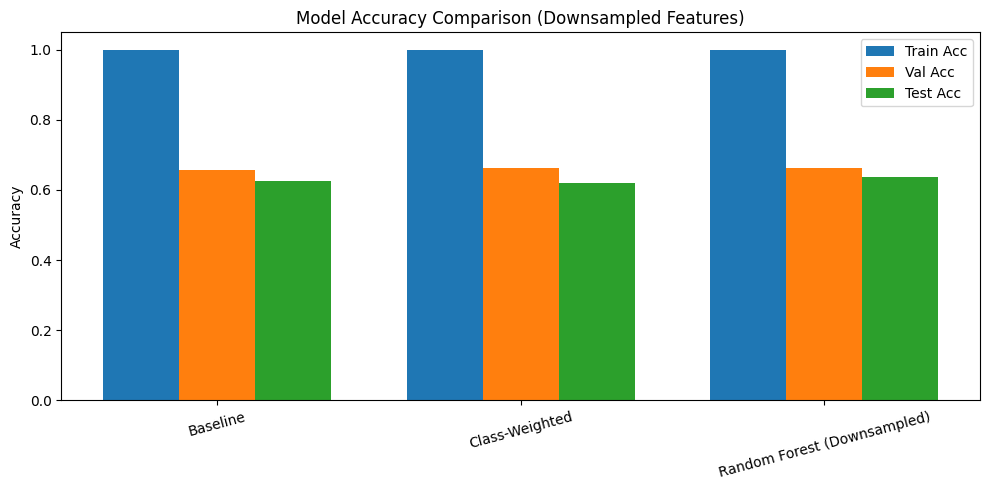

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ---------------------------------------------------
# 1. Logistic Regression (Baseline)
# ---------------------------------------------------
print("Training Baseline Logistic Regression...")
lr_base = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    n_jobs=-1
)
lr_base.fit(X_tr, y_tr)

acc_train_base = accuracy_score(y_tr, lr_base.predict(X_tr))
acc_val_base   = accuracy_score(y_val, lr_base.predict(X_val))
acc_test_base  = accuracy_score(y_test, lr_base.predict(X_test))


# ---------------------------------------------------
# 2. Logistic Regression (Class-Weighted)
# ---------------------------------------------------
print("Training Class-Weighted Logistic Regression...")
lr_bal = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    n_jobs=-1,
    class_weight="balanced"
)
lr_bal.fit(X_tr, y_tr)

acc_train_bal = accuracy_score(y_tr, lr_bal.predict(X_tr))
acc_val_bal   = accuracy_score(y_val, lr_bal.predict(X_val))
acc_test_bal  = accuracy_score(y_test, lr_bal.predict(X_test))


# ---------------------------------------------------
# 3. Random Forest Model (Downsampled Features)
# ---------------------------------------------------
print("Training Random Forest (Downsampled, Balanced)...")
rf_bal = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
rf_bal.fit(X_tr, y_tr)

acc_train_rf = accuracy_score(y_tr, rf_bal.predict(X_tr))
acc_val_rf   = accuracy_score(y_val, rf_bal.predict(X_val))
acc_test_rf  = accuracy_score(y_test, rf_bal.predict(X_test))


# ---------------------------------------------------
# 4. Build full comparison table
# ---------------------------------------------------
comparison_df = pd.DataFrame({
    "Model": [
        "Baseline",
        "Class-Weighted",
        "Random Forest (Downsampled)"
    ],
    "Train Accuracy": [
        acc_train_base,
        acc_train_bal,
        acc_train_rf
    ],
    "Val Accuracy": [
        acc_val_base,
        acc_val_bal,
        acc_val_rf
    ],
    "Test Accuracy": [
        acc_test_base,
        acc_test_bal,
        acc_test_rf
    ]
})

print("\n=== FULL MODEL COMPARISON TABLE ===")
print(comparison_df.to_string(index=False))


# ---------------------------------------------------
# 5. Make a bar chart comparison
# ---------------------------------------------------
models = comparison_df["Model"]
train_acc = comparison_df["Train Accuracy"]
val_acc   = comparison_df["Val Accuracy"]
test_acc  = comparison_df["Test Accuracy"]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,5))
plt.bar(x - width, train_acc, width, label='Train Acc')
plt.bar(x,         val_acc,   width, label='Val Acc')
plt.bar(x + width, test_acc,  width, label='Test Acc')

plt.xticks(x, models, rotation=15)
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.title("Model Accuracy Comparison (Downsampled Features)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import classification_report

print("=== Per-Class Metrics (Validation) ===")
print(classification_report(y_val, y_val_pred, digits=4))

print("=== Per-Class Metrics (Test) ===")
print(classification_report(y_test, y_test_pred, digits=4))

=== Per-Class Metrics (Validation) ===
              precision    recall  f1-score   support

           0     0.5434    0.9597    0.6939       124
           1     0.0000    0.0000    0.0000        69
           2     0.8059    0.7784    0.7919       176
           3     0.0000    0.0000    0.0000         2
           4     0.0000    0.0000    0.0000         4
           5     1.0000    0.4286    0.6000         7
           6     0.7500    0.6000    0.6667        10
           7     0.0000    0.0000    0.0000         4
           8     0.0000    0.0000    0.0000         4

    accuracy                         0.6625       400
   macro avg     0.3444    0.3074    0.3058       400
weighted avg     0.5593    0.6625    0.5907       400

=== Per-Class Metrics (Test) ===
              precision    recall  f1-score   support

           0     0.5501    0.9456    0.6956       331
           1     0.0000    0.0000    0.0000       180
           2     0.7419    0.7437    0.7428       398
      

/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/site-packag